In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, make_scorer, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import optuna
from sklearn.model_selection import StratifiedKFold, cross_validate
import joblib
from pathlib import Path

In [18]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "mushrooms_clean.csv"
df = pd.read_csv(data_path)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,s,w,w,w,o,p,k,n,g


In [19]:
X = df.drop('class', axis=1)
y = df['class']

dividir entre entrenar modelo y hacer test 80/20%

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

hacerlas categoricas onehotencoder

In [21]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), X.columns)
])

In [22]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

In [23]:
def build_pipeline(model):
    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

In [26]:
results = []

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

for name, model in models.items():

    pipe = build_pipeline(model)

    pipe.fit(X_train, y_train_enc)

    train_acc = pipe.score(X_train, y_train_enc)
    test_acc = pipe.score(X_test, y_test_enc)

    results.append({
        "Modelo": name,
        "Train": train_acc,
        "Test": test_acc,
        "Overfitting": train_acc - test_acc
    })

results_df = pd.DataFrame(results).sort_values("Test", ascending=False)
results_df

,Modelo,Train,Test,Overfitting
0,LogReg,1.0,1.0,0.0
1,RandomForest,1.0,1.0,0.0
2,GradientBoosting,1.0,1.0,0.0
3,XGBoost,1.0,1.0,0.0
4,DecisionTree,1.0,1.0,0.0


In [28]:
cv_results = {}

for name, model in models.items():

    pipe = build_pipeline(model)

    scores = cross_val_score(
    pipe,
    X_train,
    y_train_enc,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
    )

    cv_results[name] = scores.mean()

pd.DataFrame(cv_results.items(), columns=["Modelo", "CV F1"]).sort_values("CV F1", ascending=False)

,Modelo,CV F1
1,RandomForest,1.000000
3,XGBoost,1.000000
2,GradientBoosting,0.999692
4,DecisionTree,0.999692
0,LogReg,0.999075


In [30]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipe,
        X_train,
        y_train_enc,   
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction="maximize")

print("Iniciando optimización con Optuna...")

study.optimize(objective, n_trials=10)

print("Optimización finalizada")
print("Mejores parámetros:", study.best_params)
print("Mejor F1:", study.best_value)

[I 2026-06-22 10:32:51,075] A new study created in memory with name: no-name-f19a8172-a26f-4e0d-8df7-3bb8a36b0f86


Iniciando optimización con Optuna...


[I 2026-06-22 10:32:59,731] Trial 0 finished with value: 0.9992294009371424 and parameters: {'n_estimators': 101, 'max_depth': 3, 'learning_rate': 0.0745818193590245, 'subsample': 0.8200715387773938, 'colsample_bytree': 0.699815789279722}. Best is trial 0 with value: 0.9992294009371424.
[I 2026-06-22 10:33:00,274] Trial 1 finished with value: 0.9992294009371424 and parameters: {'n_estimators': 96, 'max_depth': 3, 'learning_rate': 0.10203138106164056, 'subsample': 0.7944413836845626, 'colsample_bytree': 0.9622300748234843}. Best is trial 0 with value: 0.9992294009371424.
[I 2026-06-22 10:33:00,989] Trial 2 finished with value: 0.9989212039429168 and parameters: {'n_estimators': 74, 'max_depth': 7, 'learning_rate': 0.018605016663406738, 'subsample': 0.6788963065449579, 'colsample_bytree': 0.6272546090123107}. Best is trial 0 with value: 0.9992294009371424.
[I 2026-06-22 10:33:01,896] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 240, 'max_depth': 7, 'learning_rate': 0

Optimización finalizada
Mejores parámetros: {'n_estimators': 240, 'max_depth': 7, 'learning_rate': 0.13293309330723777, 'subsample': 0.7747374764075677, 'colsample_bytree': 0.6739036555291377}
Mejor F1: 1.0



REPORTE FINAL EN TEST
              precision    recall  f1-score   support

  Comestible       1.00      1.00      1.00       842
    Venenosa       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



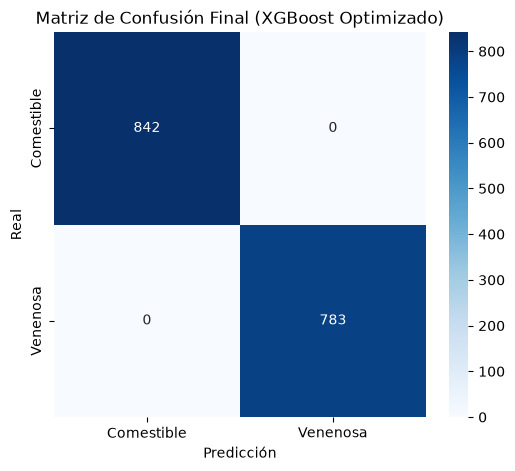

In [31]:
class_names_map = {'e': 'Comestible', 'p': 'Venenosa'}

final_params = study.best_params.copy()
final_params["random_state"] = 42

best_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(**final_params))
])

le_final = LabelEncoder()

y_train_enc = le_final.fit_transform(y_train)
y_test_enc = le_final.transform(y_test)

best_model.fit(X_train, y_train_enc)

y_pred_test = best_model.predict(X_test)

target_names = [class_names_map[c] for c in le_final.classes_]

print("\n" + "="*50)
print("REPORTE FINAL EN TEST")
print("="*50)

print(classification_report(
    y_test_enc,
    y_pred_test,
    target_names=target_names
))

cm = confusion_matrix(y_test_enc, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Matriz de Confusión Final (XGBoost Optimizado)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

<Figure size 700x600 with 0 Axes>

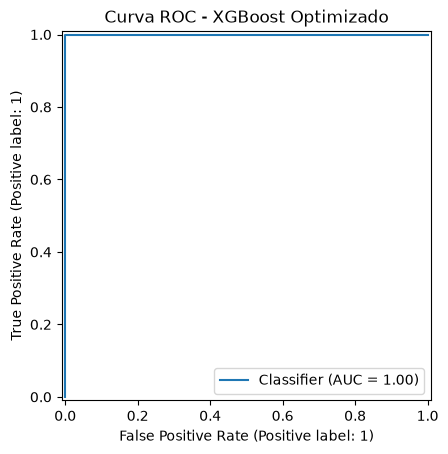

In [ ]:
# Predicciones de probabilidad (necesario para ROC)
y_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test_enc,              
    y_proba[:, 1],           
)

plt.title("Curva ROC - XGBoost Optimizado")
plt.show()

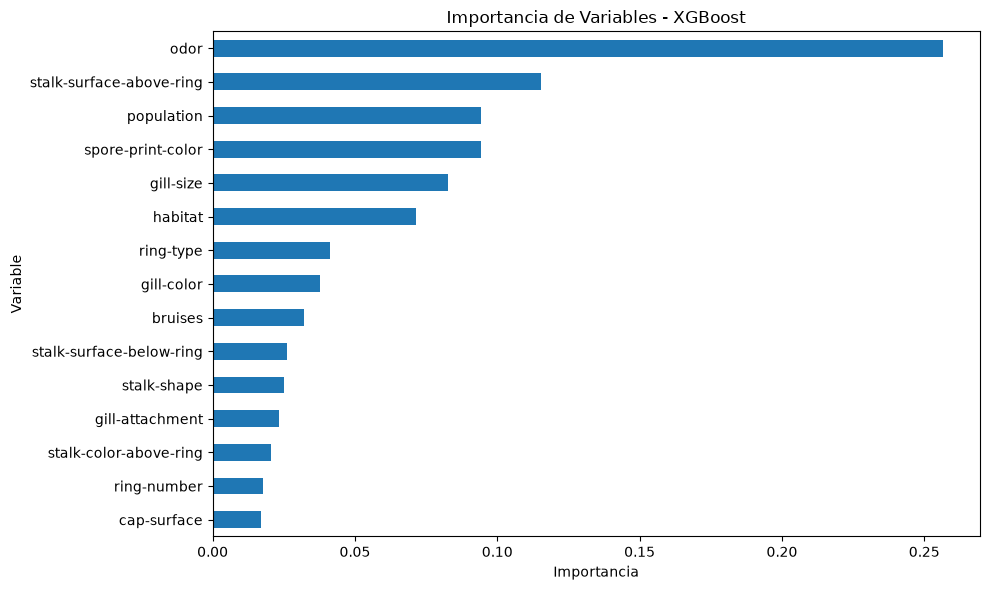

variable
odor                        0.256737
stalk-surface-above-ring    0.115456
population                  0.094309
spore-print-color           0.094252
gill-size                   0.082613
habitat                     0.071457
ring-type                   0.041203
gill-color                  0.037696
bruises                     0.032010
stalk-surface-below-ring    0.026031
stalk-shape                 0.025150
gill-attachment             0.023481
stalk-color-above-ring      0.020570
ring-number                 0.017624
cap-surface                 0.017071
Name: importance, dtype: float32

In [35]:
# 1. Modelo entrenado dentro del pipeline
model = best_model.named_steps["model"]

# 2. Nombres reales tras OneHotEncoder
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# 3. Importancias del modelo
importances = model.feature_importances_

# 4. DataFrame
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# 5. Extraer variable original correctamente
fi_df["variable"] = (
    fi_df["feature"]
    .str.split("__").str[1]      # parte después de cat__
    .str.split("_").str[0]       # nombre real de variable
)

# 6. Agrupar importancias
fi_grouped = (
    fi_df.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# 7. Gráfico
plt.figure(figsize=(10, 6))

fi_grouped.head(15).plot(kind="barh")
plt.gca().invert_yaxis()

plt.title("Importancia de Variables - XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

# 8. Output tabla
fi_grouped.head(15)

In [41]:
# 1. Crear ruta base del proyecto
BASE_DIR = Path().resolve().parent  # ajusta si ya lo usas así
models_path = BASE_DIR / "models"

# 2. Crear carpeta si no existe
models_path.mkdir(exist_ok=True)

# 3. Guardar modelo
model_file = models_path / "best_xgboost_model.pkl"

joblib.dump(best_model, model_file)

print(f"Modelo guardado en: {model_file}")

Modelo guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\models\best_xgboost_model.pkl
